# Q1

In [26]:
# ----- Q1 -----
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
from google.colab.patches import cv2_imshow

# ----------- Helper Functions -----------
def dft_image(img):
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)
    magnitude = 20 * np.log(np.abs(dft_shift) + 1)
    return dft, dft_shift, magnitude

def idft_image(dft_shift):
    f_ishift = np.fft.ifftshift(dft_shift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    return img_back

def make_filter(shape, cutoff, filter_type='ideal', highpass=False, order=2):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            if filter_type == 'ideal':
                H = 1 if D <= cutoff else 0
            elif filter_type == 'gaussian':
                H = np.exp(-(D**2) / (2 * (cutoff**2)))
            elif filter_type == 'butterworth':
                H = 1 / (1 + (D / cutoff) ** (2 * order))
            else:
                raise ValueError("Unknown filter type")

            if highpass:
                H = 1 - H
            mask[u, v] = H
    return mask

def apply_filter(img, cutoff, filter_type='ideal', highpass=False, order=2):
    dft, dft_shift, mag = dft_image(img)
    mask = make_filter(img.shape, cutoff, filter_type, highpass, order)
    filtered_shift = dft_shift * mask
    filtered_img = idft_image(filtered_shift)
    return mag, mask, filtered_img

# -----------------------------
# Wrapper for interactive exploration
# -----------------------------
def interactive_filter(image_filename, filter_type, cutoff_frequency):
    img = cv2.imread(image_filename, cv2.IMREAD_GRAYSCALE)

    # Split filter type string (e.g. "Gaussian HPF")
    ftype, pass_type = filter_type.split()
    highpass = True if pass_type == "HPF" else False

    mag, mask, filtered = apply_filter(
        img, cutoff_frequency, filter_type=ftype.lower(), highpass=highpass, order=2
    )

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(mag, cmap='gray'), plt.title("DFT Spectrum"), plt.axis("off")
    plt.subplot(1, 3, 2), plt.imshow(mask, cmap='gray'), plt.title("Filter Mask"), plt.axis("off")
    plt.subplot(1, 3, 3), plt.imshow(filtered, cmap='gray'), plt.title("Filtered Output"), plt.axis("off")
    plt.show()

# -----------------------------
# Interactive Widget
# -----------------------------
interact(
    interactive_filter,
    image_filename=widgets.Dropdown(
        options={
            'Cameraman': '/content/cameraman.jpg',
            'Einstein': '/content/einstein.png',
            'Marilyn': '/content/marilyn.png',
            'jetplane': '/content/jetplane.jpg',
            'lake': '/content/lake.jpg',
            'mandril': '/content/mandril.jpg',
            'pirate': '/content/pirate.png',
            'walkbridge': '/content/walkbridge.png',
            'lena': '/content/lena.jpg',
            'livingroom': '/content/livingroom.jpg',
        },
        value='/content/einstein.png',
        description='Image:'
    ),
    filter_type=widgets.Dropdown(
        options=['Ideal LPF', 'Ideal HPF', 'Gaussian LPF', 'Gaussian HPF', 'Butterworth LPF', 'Butterworth HPF'],
        value='Gaussian LPF',
        description='Filter:'
    ),
    cutoff_frequency=widgets.IntSlider(min=1, max=100, step=1, value=30, description='Cutoff Freq:')
)


interactive(children=(Dropdown(description='Image:', index=1, options={'Cameraman': '/content/cameraman.jpg', …

# Q2

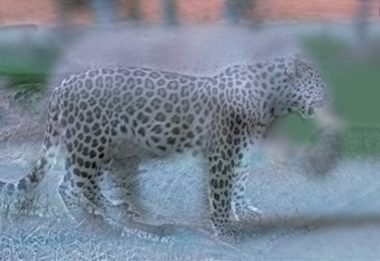

In [23]:
img_ele=plt.imread("/content/leopard_elephant.jpg")
cv2_imshow(img_ele)

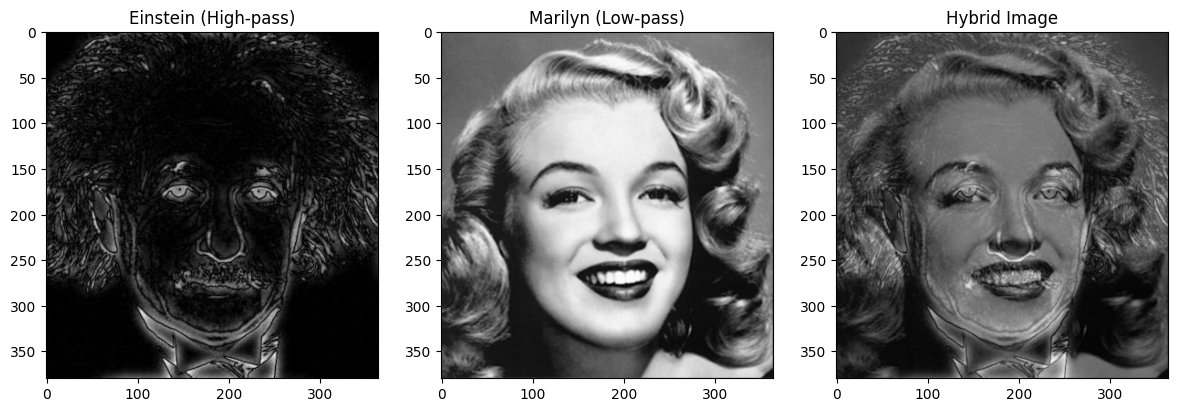

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Reuse apply_filter from Q1

def hybrid_image(img1, img2, cutoff_low=20, cutoff_high=40,
                 filter_low='gaussian', filter_high='gaussian', order=2,
                 alpha=1.2, beta=0.8):
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    img1 = cv2.resize(img1, (img2.shape[1], img2.shape[0]))

    _, _, high_einstein = apply_filter(
        img1, cutoff_high, filter_type=filter_high, highpass=True, order=order
    )
    _, _, low_marilyn = apply_filter(
        img2, cutoff_low, filter_type=filter_low, highpass=False, order=order
    )

    hybrid = alpha * high_einstein + beta * low_marilyn
    hybrid = cv2.normalize(hybrid, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return high_einstein, low_marilyn, hybrid


# ------------- Example Run -------------
einstein = cv2.imread("/content/einstein.png")
marilyn = cv2.imread("/content/marilyn.png")

high, low, hybrid = hybrid_image(
    einstein, marilyn,
    cutoff_low=80, cutoff_high=10,
    filter_low='gaussian', filter_high='gaussian',
    alpha=1.3, beta=0.7
)

# ✅ Save outputs as proper grayscale PNGs
cv2.imwrite("einstein_high.png", high.astype(np.uint8))
cv2.imwrite("marilyn_low.png", low.astype(np.uint8))
cv2.imwrite("hybrid.png", hybrid.astype(np.uint8))

# Display
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(high, cmap='gray'), plt.title("Einstein (High-pass)")
plt.subplot(1, 3, 2), plt.imshow(low, cmap='gray'), plt.title("Marilyn (Low-pass)")
plt.subplot(1, 3, 3), plt.imshow(hybrid, cmap='gray'), plt.title("Hybrid Image")
plt.tight_layout()
plt.show()


# Q3

Processing cameraman_noisy1.jpg


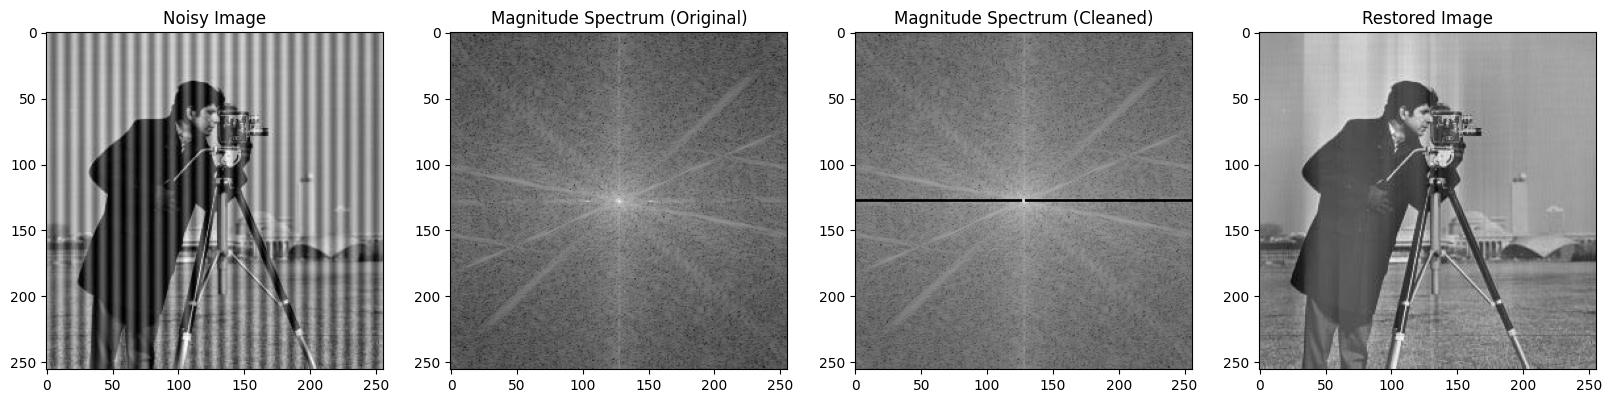

Saved restored image to cameraman_noisy1_filtered.png
Processing cameraman_noisy2.jpg


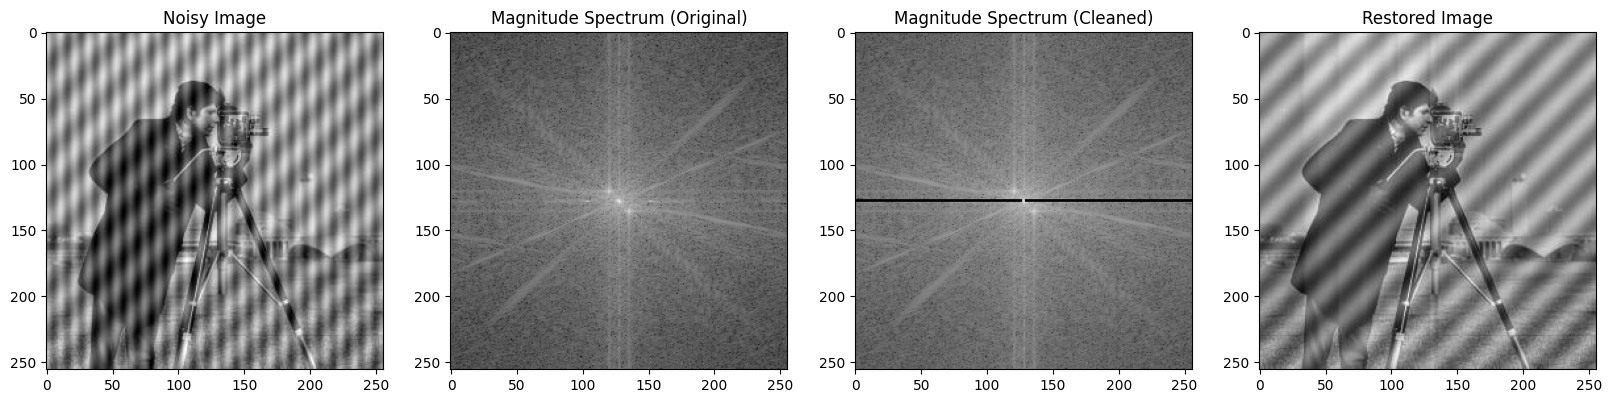

Saved restored image to cameraman_noisy2_filtered.png


In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def remove_noise(img, save_path=None):
    # FFT
    img_fft = np.fft.fftshift(np.fft.fft2(img))

    img_h, img_w = img.shape
    img_ch = img_h // 2
    img_cw = img_w // 2

    r = 1  # Radius for noise removal
    n = 1  # Width of noise removal strip

    img_fft_cleaned = img_fft.copy()

    # Zero-out noise regions
    img_fft_cleaned[img_ch - r:img_ch + r, 0:img_cw - n] = 0
    img_fft_cleaned[img_ch - r:img_ch + r, img_cw + n:] = 0

    # Restore image via inverse FFT
    img_restored = np.fft.ifft2(np.fft.ifftshift(img_fft_cleaned))
    img_restored = np.abs(img_restored)

    # Normalize for display/saving
    img_restored_norm = cv2.normalize(img_restored, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Show results
    plt.figure(figsize=(20, 20))
    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Noisy Image')

    plt.subplot(1, 4, 2)
    plt.imshow(np.log(1 + np.abs(img_fft)), cmap='gray')
    plt.title('Magnitude Spectrum (Original)')

    plt.subplot(1, 4, 3)
    plt.imshow(np.log(1 + np.abs(img_fft_cleaned)), cmap='gray')
    plt.title('Magnitude Spectrum (Cleaned)')

    plt.subplot(1, 4, 4)
    plt.imshow(img_restored_norm, cmap='gray')
    plt.title('Restored Image')

    plt.show()

    # Save filtered image if path provided
    if save_path:
        cv2.imwrite(save_path, img_restored_norm)
        print(f"Saved restored image to {save_path}")


# -------- Example Run --------
noisy_image_files = ["cameraman_noisy1.jpg", "cameraman_noisy2.jpg"]

for image_file in noisy_image_files:
    img = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)
    print(f"Processing {image_file}")
    output_file = os.path.splitext(image_file)[0] + "_filtered.png"
    remove_noise(img, save_path=output_file)
